In [14]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

data = loadmat(r'C:\Workspace\Post_Doc_Works_NTNU\Projects\2_SWE_Velocity_LV_Filling_Pressure_Digital_Twin\2_Data\SWE_patients_cathlab\0316\191211\001\191211_001.srd')
usdata = data['USData'][0, 0]

bimgData = usdata['tissue']  # shape: (height, width, frames)
ecgData = usdata['ecg'].squeeze()  # flatten to 1D if needed
velData = usdata['velocity']
print("B-mode shape:", bimgData.shape)
print("ECG shape:", ecgData.shape)
print("SWE Vel Data",velData.shape)


B-mode shape: (488, 144, 98)
ECG shape: (1987,)
SWE Vel Data (506, 144, 1759)


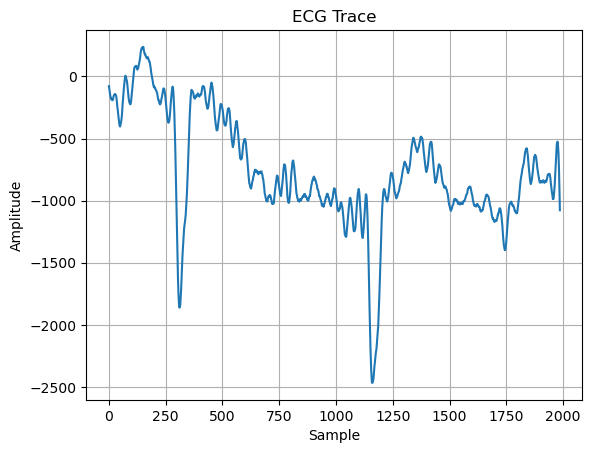

In [8]:
plt.figure()
plt.plot(ecgData)
plt.title("ECG Trace")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


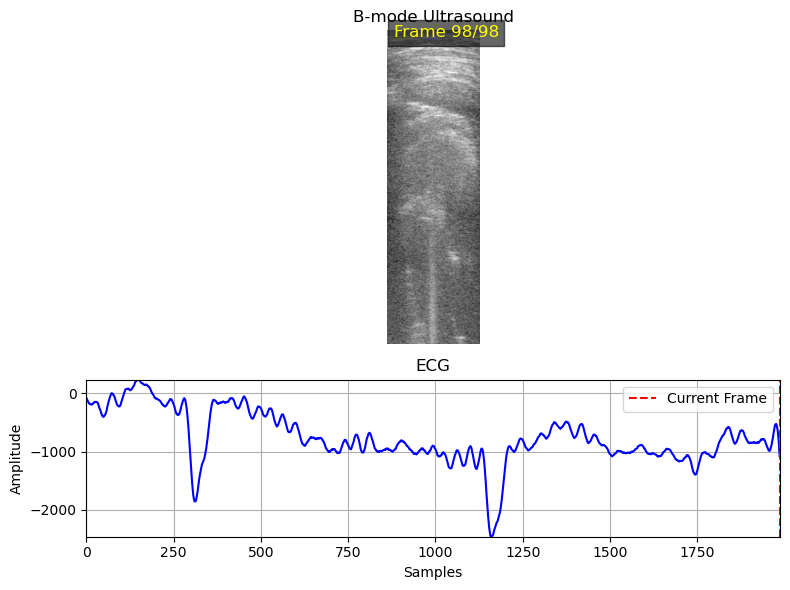

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output

# Dimensions
numFrames = bimgData.shape[2]
ecgLength = ecgData.shape[0]

# ECG index mapping for each frame
ecg_indices = np.linspace(0, ecgLength - 1, numFrames).astype(int)

for i in range(numFrames):
    clear_output(wait=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [2, 1]})

    # B-mode image with frame number text overlay
    ax1.imshow(bimgData[:, :, i], cmap='gray', aspect='equal')
    ax1.set_title("B-mode Ultrasound")
    ax1.axis('off')
    ax1.text(10, 10, f'Frame {i+1}/{numFrames}', color='yellow', fontsize=12, 
             bbox=dict(facecolor='black', alpha=0.6))

    # ECG plot with vertical marker
    ax2.plot(ecgData, color='b')
    ax2.axvline(ecg_indices[i], color='r', linestyle='--', label='Current Frame')
    ax2.set_title("ECG")
    ax2.set_xlim([0, ecgLength])
    ax2.set_ylim([ecgData.min(), ecgData.max()])
    ax2.set_xlabel("Samples")
    ax2.set_ylabel("Amplitude")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    
    time.sleep(0.05)


In [25]:
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import clear_output

# Load velocity and ECG data from usdata dict
velData = usdata['velocity']
ecgData = usdata['ecg'].squeeze()  # Convert to 1D if needed

numFrames = velData.shape[2]
ecgLength = ecgData.shape[0]

# Map frame indices to ECG sample points
ecg_indices = np.linspace(0, ecgLength - 1, numFrames).astype(int)

# Animation loop
for i in range(min(500, numFrames)):  # Use full numFrames if desired
    clear_output(wait=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [2, 1]})

    # Doppler SWE velocity image (color)
    im = ax1.imshow(velData[:, :, i], aspect='equal', cmap='jet')  # Use 'jet' for color display
    ax1.set_title("Doppler SWE Velocity Frame")
    ax1.axis('off')
    ax1.text(10, 10, f'Frame {i+1}/{numFrames}', color='white', fontsize=12,
             bbox=dict(facecolor='black', alpha=0.6))

    # Add colorbar for velocity scale
    fig.colorbar(im, ax=ax1, orientation='vertical', shrink=0.8)

    # ECG signal with vertical line showing current frame location
    ax2.plot(ecgData, color='blue')
    ax2.axvline(ecg_indices[i], color='red', linestyle='--', label='Current Frame')
    ax2.set_title("ECG Trace")
    ax2.set_xlim([0, ecgLength])
    ax2.set_ylim([ecgData.min(), ecgData.max()])
    ax2.set_xlabel("Samples")
    ax2.set_ylabel("Amplitude")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    #time.sleep(0.0001)  # ~20 fps




KeyboardInterrupt: 